# Loan Portfolio & Credit Analytics EDA

**Banking Analytics Intelligence Platform** — Tanzania Banking Portfolio

This notebook analyzes loan portfolio size, product mix, repayment health, credit risk, and regional exposure for management decision-making.


In [1]:
# Reusable loan analytics utilities
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

PROJECT_ROOT = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'loan_analysis'
CHART_DIR = REPORT_DIR / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14, 'axes.labelsize': 12})

VALID_LOAN_STATUSES = {'Active', 'Closed', 'Defaulted'}
VALID_REPAYMENT_STATUSES = {'On Time', 'Late', 'Default'}
VALID_RISK_CATEGORIES = {'Low Risk', 'Medium Risk', 'High Risk'}


def format_tzs(value: float) -> str:
    """Format Tanzanian shilling values for credit committee reporting."""
    if value >= 1_000_000_000:
        return f'TZS {value / 1_000_000_000:.2f} Billion'
    if value >= 1_000_000:
        return f'TZS {value / 1_000_000:.2f} Million'
    return f'TZS {value:,.0f}'


def load_loan_datasets(processed_dir: Path = PROCESSED_DIR):
    """Load cleaned loan and customer datasets."""
    loans = pd.read_csv(processed_dir / 'loans_clean.csv', parse_dates=['loan_date'])
    customers = pd.read_csv(
        processed_dir / 'customers_clean.csv',
        parse_dates=['date_of_birth', 'customer_since'],
    )
    return loans, customers


def summarize_dataset(df: pd.DataFrame, name: str) -> None:
    """Display structure and quality checks for a dataset."""
    print(f'\n=== {name} ===')
    display(df.head())
    print(f'Shape: {df.shape}')
    print('Columns:', list(df.columns))
    print('\nData types:')
    print(df.dtypes)
    missing = df.isna().sum()
    missing = missing[missing > 0]
    print('\nMissing values:')
    print(missing if not missing.empty else 'None')
    print(f'Duplicate rows: {df.duplicated().sum():,}')


def validate_loan_values(loans: pd.DataFrame) -> pd.DataFrame:
    """Filter invalid loan records before credit analytics."""
    validated = loans.copy()
    validated = validated[validated['loan_status'].isin(VALID_LOAN_STATUSES)]
    validated = validated[validated['repayment_status'].isin(VALID_REPAYMENT_STATUSES)]
    validated = validated[validated['risk_category'].isin(VALID_RISK_CATEGORIES)]
    validated = validated[(validated['loan_amount'] > 0) & (validated['interest_rate'] > 0)]
    return validated.reset_index(drop=True)


def build_loan_kpis(loans: pd.DataFrame) -> pd.DataFrame:
    """Compute portfolio-level loan KPIs for executive reporting."""
    total_amount = loans['loan_amount'].sum()
    return pd.DataFrame({
        'Metric': [
            'Total Number of Loans',
            'Portfolio Value',
            'Average Loan Size',
            'Maximum Loan Amount',
            'Minimum Loan Amount',
            'Average Interest Rate',
            'Active Loans Count',
        ],
        'Value': [
            f"{len(loans):,}",
            format_tzs(total_amount),
            format_tzs(loans['loan_amount'].mean()),
            format_tzs(loans['loan_amount'].max()),
            format_tzs(loans['loan_amount'].min()),
            f"{loans['interest_rate'].mean():.2f}%",
            f"{(loans['loan_status'] == 'Active').sum():,}",
        ],
    })


def loan_product_summary(loans: pd.DataFrame) -> pd.DataFrame:
    """Summarize loan count and value by product type."""
    return (
        loans.groupby('loan_type', as_index=False)
        .agg(
            loan_count=('loan_id', 'count'),
            total_loan_amount=('loan_amount', 'sum'),
            average_loan_amount=('loan_amount', 'mean'),
        )
        .sort_values('total_loan_amount', ascending=False)
    )


def repayment_analysis(loans: pd.DataFrame) -> pd.DataFrame:
    """Summarize repayment behavior distribution."""
    summary = loans['repayment_status'].value_counts().reset_index()
    summary.columns = ['repayment_status', 'repayment_count']
    summary['percentage_distribution'] = (
        summary['repayment_count'] / summary['repayment_count'].sum() * 100
    ).round(2)
    return summary


def calculate_npl_rate(loans: pd.DataFrame) -> float:
    """Calculate Non-Performing Loan rate (Late + Default)."""
    non_performing = loans['repayment_status'].isin(['Late', 'Default']).sum()
    return non_performing / len(loans) * 100


def risk_analysis_summary(loans: pd.DataFrame) -> pd.DataFrame:
    """Summarize exposure by risk category."""
    summary = (
        loans.groupby('risk_category', as_index=False)
        .agg(
            loan_count=('loan_id', 'count'),
            total_loan_amount=('loan_amount', 'sum'),
            default_count=('repayment_status', lambda s: (s == 'Default').sum()),
        )
    )
    summary['loan_share_pct'] = (summary['loan_count'] / summary['loan_count'].sum() * 100).round(2)
    summary['default_rate_pct'] = (summary['default_count'] / summary['loan_count'] * 100).round(2)
    return summary.sort_values('loan_count', ascending=False)


def default_rate_by_column(loans_customers: pd.DataFrame, column: str) -> pd.DataFrame:
    """Compute default rate for a customer attribute segment."""
    summary = (
        loans_customers.groupby(column, as_index=False)
        .agg(
            loan_count=('loan_id', 'count'),
            default_count=('repayment_status', lambda s: (s == 'Default').sum()),
            total_loan_amount=('loan_amount', 'sum'),
        )
    )
    summary['default_rate_pct'] = (summary['default_count'] / summary['loan_count'] * 100).round(2)
    return summary.sort_values('default_rate_pct', ascending=False)


def regional_loan_summary(loans_customers: pd.DataFrame) -> pd.DataFrame:
    """Analyze loan exposure and default rate by region."""
    summary = (
        loans_customers.groupby('region', as_index=False)
        .agg(
            loan_count=('loan_id', 'count'),
            total_loan_amount=('loan_amount', 'sum'),
            default_count=('repayment_status', lambda s: (s == 'Default').sum()),
        )
    )
    summary['default_rate'] = (summary['default_count'] / summary['loan_count'] * 100).round(2)
    return summary.sort_values('total_loan_amount', ascending=False)


def assign_loan_size_category(amount: float) -> str:
    """Classify loans into small, medium, and large buckets (TZS)."""
    if amount < 1_000_000:
        return 'Small Loan'
    if amount <= 10_000_000:
        return 'Medium Loan'
    return 'Large Loan'


def save_figure(fig, filename: str) -> Path:
    """Save chart for credit risk reporting packs."""
    output_path = CHART_DIR / filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return output_path


## Section 1: Load Data

Load cleaned loan and customer datasets and validate credit records.

In [2]:
loans_raw, customers = load_loan_datasets()
summarize_dataset(loans_raw, 'Loans (raw)')
summarize_dataset(customers, 'Customers')

loans = validate_loan_values(loans_raw)
print(f'\nValidated loans retained: {len(loans):,} of {len(loans_raw):,}')

loans_customers = loans.merge(customers, on='customer_id', how='left')



=== Loans (raw) ===


,loan_id,customer_id,loan_type,loan_amount,interest_rate,loan_date,duration_months,repayment_status,loan_status,risk_category
0,LOAN000001,CUST008926,Mortgage,461610500,11.15,2025-12-09,103,On Time,Active,Low Risk
1,LOAN000002,CUST077396,Education Loan,19385400,16.02,2026-09-01,172,On Time,Active,Low Risk
2,LOAN000003,CUST065458,Mortgage,1000000000,11.81,2026-07-12,140,On Time,Active,Low Risk
3,LOAN000004,CUST043888,Education Loan,10759700,15.95,2025-12-14,33,On Time,Active,Low Risk
4,LOAN000005,CUST043302,Mortgage,274546100,12.23,2022-10-28,120,On Time,Active,Low Risk


Shape: (50000, 10)
Columns: ['loan_id', 'customer_id', 'loan_type', 'loan_amount', 'interest_rate', 'loan_date', 'duration_months', 'repayment_status', 'loan_status', 'risk_category']

Data types:
loan_id                        str
customer_id                    str
loan_type                      str
loan_amount                  int64
interest_rate              float64
loan_date           datetime64[us]
duration_months              int64
repayment_status               str
loan_status                    str
risk_category                  str
dtype: object

Missing values:
None
Duplicate rows: 0

=== Customers ===


,customer_id,full_name,gender,date_of_birth,age,region,occupation,income_level,customer_since,customer_type,customer_age_group
0,CUST000001,Allison Hill,Male,1984-09-01,41,Zanzibar,Self Employed,Medium,2015-08-31,Basic,31-45
1,CUST000002,Noah Rhodes,Female,1955-10-05,70,Kilimanjaro,Self Employed,Low,2009-03-05,Basic,60+
2,CUST000003,Angie Henderson,Female,1997-11-18,28,Morogoro,Self Employed,Medium,2014-05-16,Standard,18-30
3,CUST000004,Daniel Wagner,Male,2006-12-06,19,Mbeya,Self Employed,Medium,2024-12-26,Standard,18-30
4,CUST000005,Cristian Santos,Male,1972-08-29,53,Dar es Salaam,Bank Officer,Low,2021-02-14,Basic,46-60


Shape: (100000, 11)
Columns: ['customer_id', 'full_name', 'gender', 'date_of_birth', 'age', 'region', 'occupation', 'income_level', 'customer_since', 'customer_type', 'customer_age_group']

Data types:
customer_id                      str
full_name                        str
gender                           str
date_of_birth         datetime64[us]
age                            int64
region                           str
occupation                       str
income_level                     str
customer_since        datetime64[us]
customer_type                    str
customer_age_group               str
dtype: object

Missing values:
None
Duplicate rows: 0

Validated loans retained: 50,000 of 50,000


## Section 2: Loan Portfolio Overview

Executive KPIs describing portfolio scale and pricing.

In [3]:
loan_portfolio_summary = build_loan_kpis(loans)
display(loan_portfolio_summary)


,Metric,Value
0,Total Number of Loans,"50,000"
1,Portfolio Value,TZS 7590.46 Billion
2,Average Loan Size,TZS 151.81 Million
3,Maximum Loan Amount,TZS 1.00 Billion
4,Minimum Loan Amount,TZS 1.17 Million
5,Average Interest Rate,16.50%
6,Active Loans Count,"38,375"


## Section 3: Loan Product Analysis

Identify which lending products drive volume and portfolio value.

In [4]:
product_summary = loan_product_summary(loans)
display(product_summary.assign(
    total_loan_amount_tzs=product_summary['total_loan_amount'].map(format_tzs),
    average_loan_amount_tzs=product_summary['average_loan_amount'].map(format_tzs),
))

top_product = product_summary.iloc[0]
print(f"Insight: {top_product['loan_type']} loans represent the largest share of portfolio value ({format_tzs(top_product['total_loan_amount'])}).")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=product_summary, x='loan_type', y='loan_count', hue='loan_type', palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('Number of Loans by Type')
axes[0].set_xlabel('Loan Type')
axes[0].set_ylabel('Loan Count')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=product_summary, x='loan_type', y='total_loan_amount', hue='loan_type', palette='Greens_d', legend=False, ax=axes[1])
axes[1].set_title('Loan Value by Type')
axes[1].set_xlabel('Loan Type')
axes[1].set_ylabel('Total Loan Amount (TZS)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e12:.1f}T'))
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
save_figure(fig, 'loan_products.png')
plt.show()


,loan_type,loan_count,total_loan_amount,average_loan_amount,total_loan_amount_tzs,average_loan_amount_tzs
2,Mortgage,9951,5696734522900,5.724786e+08,TZS 5696.73 Billion,TZS 572.48 Million
0,Business Loan,10019,1118394782700,1.116274e+08,TZS 1118.39 Billion,TZS 111.63 Million
4,Vehicle Loan,10154,468110066400,4.610105e+07,TZS 468.11 Billion,TZS 46.10 Million
3,Personal Loan,9955,166753299900,1.675071e+07,TZS 166.75 Billion,TZS 16.75 Million
1,Education Loan,9921,140472044700,1.415906e+07,TZS 140.47 Billion,TZS 14.16 Million


Insight: Mortgage loans represent the largest share of portfolio value (TZS 5696.73 Billion).


## Section 4: Loan Status Analysis

Assess performing vs non-performing loans. `Closed` loans represent completed/paid-off facilities.

,loan_status,loan_count,percentage
0,Active,38375,76.75
1,Closed,9093,18.19
2,Defaulted,2532,5.06


Performing loans (Active + Closed): 94.9%


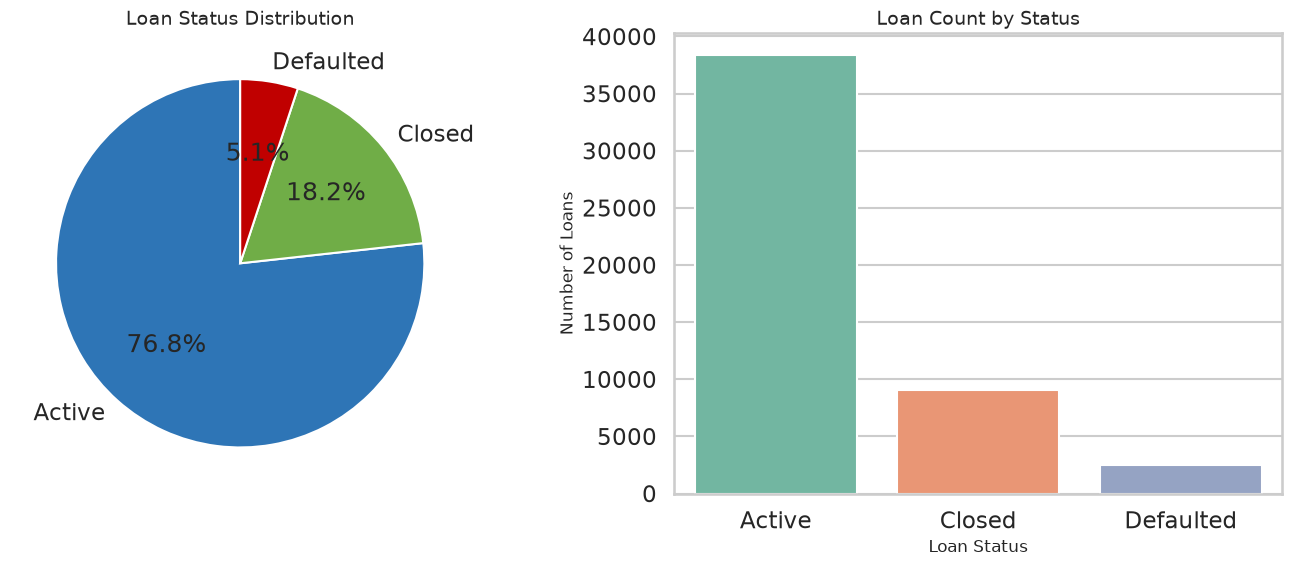

In [5]:
status_distribution = loans['loan_status'].value_counts().reset_index()
status_distribution.columns = ['loan_status', 'loan_count']
status_distribution['percentage'] = (status_distribution['loan_count'] / status_distribution['loan_count'].sum() * 100).round(2)
display(status_distribution)

performing_pct = status_distribution.loc[status_distribution['loan_status'].isin(['Active', 'Closed']), 'percentage'].sum()
print(f'Performing loans (Active + Closed): {performing_pct:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(status_distribution['loan_count'], labels=status_distribution['loan_status'], autopct='%1.1f%%', startangle=90, colors=['#2e75b6', '#70ad47', '#c00000'])
axes[0].set_title('Loan Status Distribution')
sns.barplot(data=status_distribution, x='loan_status', y='loan_count', hue='loan_status', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Loan Count by Status')
axes[1].set_xlabel('Loan Status')
axes[1].set_ylabel('Number of Loans')
plt.tight_layout()
plt.show()


## Section 5: Repayment Performance Analysis

Measure repayment health and Non-Performing Loan (NPL) exposure.

In [6]:
repayment_df = repayment_analysis(loans)
display(repayment_df)

npl_rate = calculate_npl_rate(loans)
print(f'NPL Rate (Late + Default): {npl_rate:.2f}%')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=repayment_df, x='repayment_status', y='repayment_count', hue='repayment_status', palette='RdYlGn', legend=False, ax=ax)
ax.set_title('Repayment Status Distribution')
ax.set_xlabel('Repayment Status')
ax.set_ylabel('Number of Loans')
plt.tight_layout()
save_figure(fig, 'repayment_status.png')
plt.show()


,repayment_status,repayment_count,percentage_distribution
0,On Time,41013,82.03
1,Late,6455,12.91
2,Default,2532,5.06


NPL Rate (Late + Default): 17.97%


## Section 6: Loan Risk Analysis

Analyze exposure across Low, Medium, and High risk categories.

In [7]:
risk_df = risk_analysis_summary(loans)
display(risk_df)

high_risk_exposure = risk_df.loc[risk_df['risk_category'] == 'High Risk', 'total_loan_amount'].sum()
high_risk_pct = risk_df.loc[risk_df['risk_category'] == 'High Risk', 'loan_share_pct'].iloc[0]
print(f'High Risk exposure: {format_tzs(high_risk_exposure)} ({high_risk_pct:.1f}% of loans)')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=risk_df, x='risk_category', y='loan_count', hue='risk_category', palette='Reds', legend=False, ax=ax)
ax.set_title('Risk Category Distribution')
ax.set_xlabel('Risk Category')
ax.set_ylabel('Number of Loans')
plt.tight_layout()
save_figure(fig, 'risk_distribution.png')
plt.show()


,risk_category,loan_count,total_loan_amount,default_count,loan_share_pct,default_rate_pct
1,Low Risk,41013,6208443383800,0,82.03,0.0
2,Medium Risk,6455,997109921000,0,12.91,0.0
0,High Risk,2532,384911411800,2532,5.06,100.0


High Risk exposure: TZS 384.91 Billion (5.1% of loans)


## Section 7: Customer Risk Profile Analysis

Identify customer segments with elevated default rates.

,segment_value,loan_count,default_count,total_loan_amount,default_rate_pct,dimension
0,46-60,13255,679,2004690150700,5.12,customer_age_group
1,60+,12419,627,1913013177500,5.05,customer_age_group
2,31-45,13109,661,1977259764600,5.04,customer_age_group
3,18-30,11217,565,1695501623800,5.04,customer_age_group
4,Entrepreneur,3265,182,489784671000,5.57,occupation
5,Driver,3399,188,507583923000,5.53,occupation
6,Teacher,3215,176,505875733000,5.47,occupation
7,Business Owner,3345,181,514574040300,5.41,occupation
8,Farmer,3477,181,499182014400,5.21,occupation
9,Nurse,3368,175,520232631900,5.20,occupation


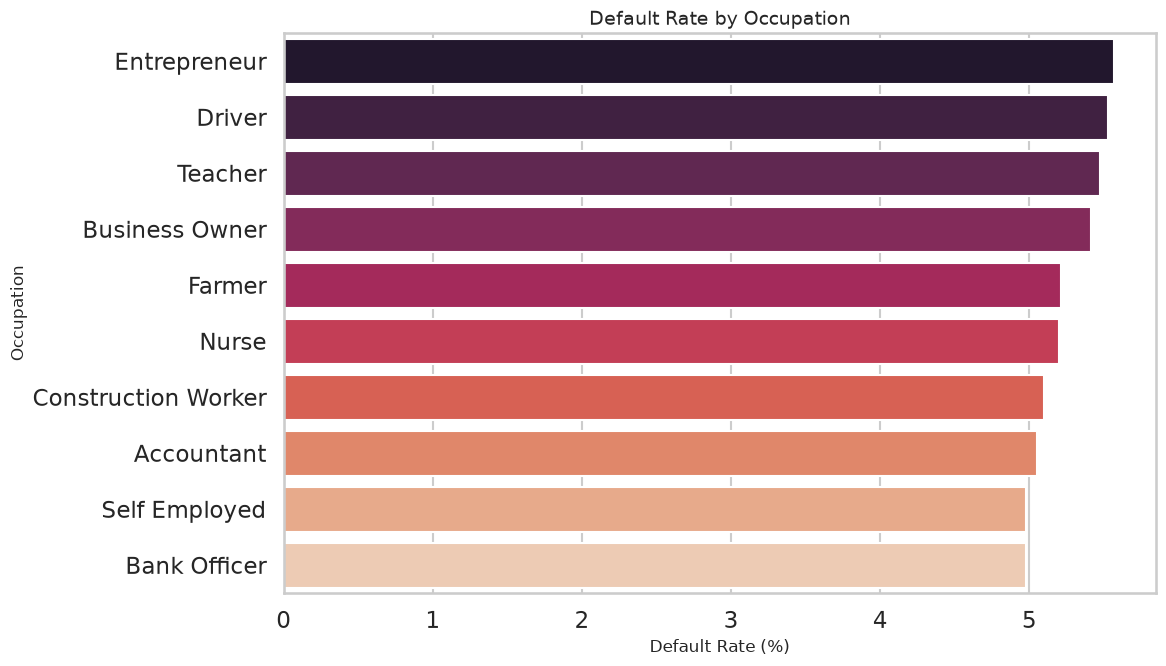

Insight: Entrepreneur shows the highest default rate (5.57%) vs Bank Officer (4.98%).


In [8]:
risk_dimensions = ['customer_age_group', 'occupation', 'income_level', 'customer_type', 'region']
customer_risk_frames = []

for dimension in risk_dimensions:
    segment = default_rate_by_column(loans_customers, dimension)
    segment['dimension'] = dimension
    segment = segment.rename(columns={dimension: 'segment_value'})
    customer_risk_frames.append(segment)

customer_risk_profile = pd.concat(customer_risk_frames, ignore_index=True)
display(customer_risk_profile.head(10))

occupation_risk = default_rate_by_column(loans_customers, 'occupation').head(10)
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=occupation_risk, y='occupation', x='default_rate_pct', hue='occupation', palette='rocket', legend=False, ax=ax)
ax.set_title('Default Rate by Occupation')
ax.set_xlabel('Default Rate (%)')
ax.set_ylabel('Occupation')
plt.tight_layout()
plt.show()

highest_occ = occupation_risk.iloc[0]
lowest_occ = occupation_risk.iloc[-1]
print(f"Insight: {highest_occ['occupation']} shows the highest default rate ({highest_occ['default_rate_pct']:.2f}%) vs {lowest_occ['occupation']} ({lowest_occ['default_rate_pct']:.2f}%).")


## Section 8: Regional Loan Analysis

Compare loan exposure and default rates across Tanzania regions.

In [9]:
regional_df = regional_loan_summary(loans_customers)
display(regional_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=regional_df, x='region', y='total_loan_amount', hue='region', palette='crest', legend=False, ax=axes[0])
axes[0].set_title('Loan Amount by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Loan Amount (TZS)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e12:.1f}T'))
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=regional_df.sort_values('default_rate', ascending=False), x='region', y='default_rate', hue='region', palette='Reds', legend=False, ax=axes[1])
axes[1].set_title('Default Rate by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
save_figure(fig, 'regional_loan_analysis.png')
plt.show()


,region,loan_count,total_loan_amount,default_count,default_rate
4,Mbeya,5161,802438321300,251,4.86
7,Tabora,5107,787178957300,284,5.56
6,Mwanza,5121,781521579000,277,5.41
2,Dodoma,5090,778230169700,245,4.81
8,Tanga,5004,766861479400,250,5.00
5,Morogoro,4945,762275587600,250,5.06
9,Zanzibar,5017,740646608100,236,4.70
1,Dar es Salaam,4933,730369923100,246,4.99
0,Arusha,4884,727736546700,264,5.41
3,Kilimanjaro,4738,713205544400,229,4.83


## Section 9: Loan Size Analysis

Analyze concentration and default risk across loan size buckets.

In [10]:
loans['loan_size_category'] = loans['loan_amount'].apply(assign_loan_size_category)
size_summary = (
    loans.groupby('loan_size_category', as_index=False)
    .agg(
        loan_count=('loan_id', 'count'),
        default_count=('repayment_status', lambda s: (s == 'Default').sum()),
    )
)
size_summary['default_rate_pct'] = (size_summary['default_count'] / size_summary['loan_count'] * 100).round(2)
size_order = ['Small Loan', 'Medium Loan', 'Large Loan']
size_summary['loan_size_category'] = pd.Categorical(size_summary['loan_size_category'], categories=size_order, ordered=True)
size_summary = size_summary.sort_values('loan_size_category')
display(size_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(loans['loan_amount'], bins=40, kde=True, color='#1f4e79', ax=axes[0])
axes[0].set_title('Loan Amount Distribution')
axes[0].set_xlabel('Loan Amount (TZS)')
axes[0].set_ylabel('Number of Loans')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

sns.barplot(data=size_summary, x='loan_size_category', y='default_rate_pct', hue='loan_size_category', palette='OrRd', legend=False, ax=axes[1])
axes[1].set_title('Default Rate by Loan Size Category')
axes[1].set_xlabel('Loan Size Category')
axes[1].set_ylabel('Default Rate (%)')
plt.tight_layout()
save_figure(fig, 'loan_size_distribution.png')
plt.show()


,loan_size_category,loan_count,default_count,default_rate_pct
1,Medium Loan,6075,303,4.99
0,Large Loan,43925,2229,5.07


## Section 10: Loan Analytics Insights

Credit risk findings for the bank management team.


In [11]:
insights = []
total_portfolio = loans['loan_amount'].sum()
top_product = product_summary.iloc[0]
on_time_pct = repayment_df.loc[repayment_df['repayment_status'] == 'On Time', 'percentage_distribution'].iloc[0]
default_pct = repayment_df.loc[repayment_df['repayment_status'] == 'Default', 'percentage_distribution'].iloc[0]
top_region = regional_df.iloc[0]
highest_risk_region = regional_df.sort_values('default_rate', ascending=False).iloc[0]
largest_size = size_summary.sort_values('loan_count', ascending=False).iloc[0]
highest_risk_size = size_summary.sort_values('default_rate_pct', ascending=False).iloc[0]
high_risk_row = risk_df.loc[risk_df['risk_category'] == 'High Risk'].iloc[0]
active_pct = (loans['loan_status'] == 'Active').mean() * 100

insights.extend([
    f"1. {top_product['loan_type']} loans represent the largest portfolio value at {format_tzs(top_product['total_loan_amount'])}.",
    f"2. Total loan portfolio value is {format_tzs(total_portfolio)} across {len(loans):,} facilities.",
    f"3. On-time repayment rate is {on_time_pct:.1f}%, indicating generally healthy portfolio performance.",
    f"4. NPL rate (Late + Default) stands at {npl_rate:.2f}%, a key credit risk indicator for management.",
    f"5. Default rate is {default_pct:.1f}% and requires targeted collections strategy.",
    f"6. High Risk loans account for {high_risk_row['loan_share_pct']:.1f}% of the portfolio ({format_tzs(high_risk_row['total_loan_amount'])} exposure).",
    f"7. {top_region['region']} has the highest loan exposure ({format_tzs(top_region['total_loan_amount'])}).",
    f"8. {highest_risk_region['region']} shows the highest regional default rate ({highest_risk_region['default_rate']:.2f}%) and needs closer monitoring.",
    f"9. {highest_occ['occupation']} customers show higher default rates than {lowest_occ['occupation']} customers.",
    f"10. {highest_risk_size['loan_size_category']} loans carry the highest default rate ({highest_risk_size['default_rate_pct']:.2f}%).",
    f"11. {active_pct:.1f}% of loans remain Active, reflecting ongoing portfolio growth.",
    f"12. {largest_size['loan_size_category']} is the most common loan size segment by volume.",
])
for insight in insights:
    print(insight)


1. Mortgage loans represent the largest portfolio value at TZS 5696.73 Billion.
2. Total loan portfolio value is TZS 7590.46 Billion across 50,000 facilities.
3. On-time repayment rate is 82.0%, indicating generally healthy portfolio performance.
4. NPL rate (Late + Default) stands at 17.97%, a key credit risk indicator for management.
5. Default rate is 5.1% and requires targeted collections strategy.
6. High Risk loans account for 5.1% of the portfolio (TZS 384.91 Billion exposure).
7. Mbeya has the highest loan exposure (TZS 802.44 Billion).
8. Tabora shows the highest regional default rate (5.56%) and needs closer monitoring.
9. Entrepreneur customers show higher default rates than Bank Officer customers.
10. Large Loan loans carry the highest default rate (5.07%).
11. 76.8% of loans remain Active, reflecting ongoing portfolio growth.
12. Large Loan is the most common loan size segment by volume.


## Section 11: Export Results

Save credit analytics tables and charts for reporting.

In [12]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)
loan_portfolio_summary.to_csv(REPORT_DIR / 'loan_portfolio_summary.csv', index=False)
product_summary.to_csv(REPORT_DIR / 'loan_product_summary.csv', index=False)
repayment_df.to_csv(REPORT_DIR / 'repayment_analysis.csv', index=False)
risk_df.to_csv(REPORT_DIR / 'risk_analysis.csv', index=False)
regional_df.to_csv(REPORT_DIR / 'regional_loan_analysis.csv', index=False)
customer_risk_profile.to_csv(REPORT_DIR / 'customer_risk_profile.csv', index=False)

print('Exported reports:')
for file in [
    'loan_portfolio_summary.csv',
    'loan_product_summary.csv',
    'repayment_analysis.csv',
    'risk_analysis.csv',
    'regional_loan_analysis.csv',
    'customer_risk_profile.csv',
]: 
    print(f' - {REPORT_DIR / file}')
print('\nExported charts:')
for chart in sorted(CHART_DIR.glob('*.png')):
    print(f' - {chart}')


Exported reports:
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/loan_analysis/loan_portfolio_summary.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/loan_analysis/loan_product_summary.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/loan_analysis/repayment_analysis.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/loan_analysis/risk_analysis.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/loan_analysis/regional_loan_analysis.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/loan_analysis/customer_risk_profile.csv

Exported charts:
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/loan_analysis/charts/loan_products.png
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/loan_analysis/charts/loan_size_distribution.png
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/loan_analysis/charts/regional_loan_analysis.png
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/loan_analysis/charts/repayment_status.p